In [1]:
import xarray as xr
import numpy as np

import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
import dpa_ensemble as de
import importlib

In [2]:
dpa_100_ens_raw = xr.open_dataset("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_30epochs/raw_dpa_ens_100_dataset_restored.nc")
dpa_100_ens_raw

<xarray.Dataset> Size: 17GB
Dimensions:          (ensemble_member: 100, time: 64000, lat_x_lon: 648)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 0...
  * lat_x_lon        (lat_x_lon) int64 5kB 0 1 2 3 4 5 ... 643 644 645 646 647
Data variables:
    TREFHT           (ensemble_member, time, lat_x_lon) float32 17GB ...

In [3]:
dpa_ens_100_restored = xr.open_dataset("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_30epochs/dpa_ens_100_dataset_restored.nc")
dpa_ens_100_restored

<xarray.Dataset> Size: 26GB
Dimensions:          (ensemble_member: 100, time: 64000, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 26GB ...

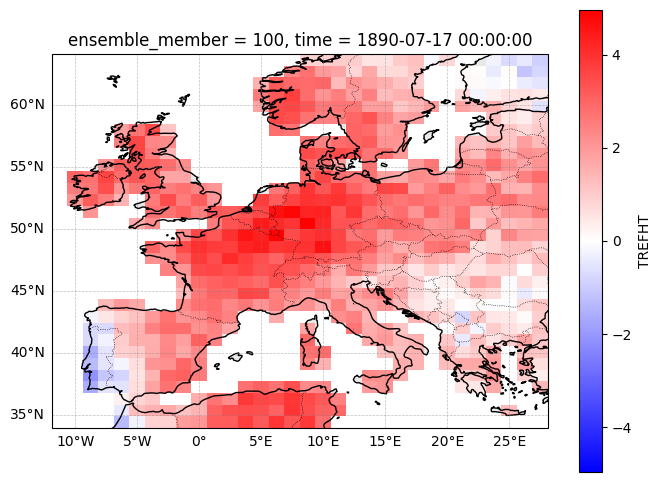

In [4]:
import importlib 
importlib.reload(ut)

dpa_restored_memb100 = dpa_ens_100_restored.isel(ensemble_member=99, time=60000).TREFHT
#dpa_restored_memb100.plot()
fig, ax = ut.plot_map(dpa_restored_memb100, cmap_label = "TREFHT")

# European T mean DPA Ensemble vs. LE

In [5]:
importlib.reload(de)

ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# load data

z500_test, mask_x_te, ds, ds_test, x_te_reduced = de.load_test_data()

# reshape mask
mask_xr = ut.torch_to_dataarray(mask_x_te.unsqueeze(0), ds, lat_dim=32, lon_dim=32, name="Mask") # mask_x_te.unsqueeze(0) adds dimension for torch_to_dataarray function to work properly

### True (Test) temperature ###


# DPA Ensemble
dpa_ens_100_restored = xr.open_dataset("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_30epochs/dpa_ens_100_dataset_restored.nc")
dpa_ens_100_restored



torch.Size([128000, 1024])
torch.Size([64000, 1024])
z500 dataset shape (476900, 1001)
z500 shape torch.Size([476900, 1001])


<xarray.Dataset> Size: 26GB
Dimensions:          (ensemble_member: 100, time: 64000, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 26GB ...

In [ ]:
dpa_ens_mean_entire_domain = dpa_100_ens_raw.mean(dim = ("ensemble_member", "lat_x_lon"))

In [4]:
# reshape mask (torch array -> xarray)
mask_xr.isel

<bound method DataArray.isel of <xarray.DataArray 'Mask' (lat: 32, lon: 32, time: 1)> Size: 1kB
array([[[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [ True],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
...
        ...,
        [ True],
        [ True],
        [ True]],

       [[False],
        [False],
        [False],
        ...,
        [ True],
        [ True],
        [ True]],

       [[False],
        [False],
        [False],
        ...,
        [ True],
        [ True],
        [ True]]], shape=(32, 32, 1))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 8B 0>

In [6]:
# Large ensemble masked
# need to unstack
le_masked = ds.TREFHT.where(mask_xr.isel(time=0))
le_masked

<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 476900)> Size: 2GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
          9.356659  ,  8.687897  ],
        [ 3.8078918 ,  5.4927063 ,  4.8749695 , ..., 10.609314  ,
          9.962189  ,  8.511993  ],
        [ 3.5441284 ,  5.477997  ,  5.2870483 , ..., 10.813477  ,
         10.184113  ,  8.559998  ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 3.8385315 ,  5.002594  ,  4.5272217 , ..., 10.830597  ,
          8.545502  ,  8.909454  ],
        [ 3.714203  ,  5.217743  ,  4.992737  , ..., 10.833099  ,
          9.090546  ,  8.789795  ],
        [ 3.6059875 ,  5.5631104 ,  5.5166016 , ..., 11.494293  ,
          9.7612    ,  8.645752  ]]],
      shape=(32, 32, 476900), dtype=float32)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

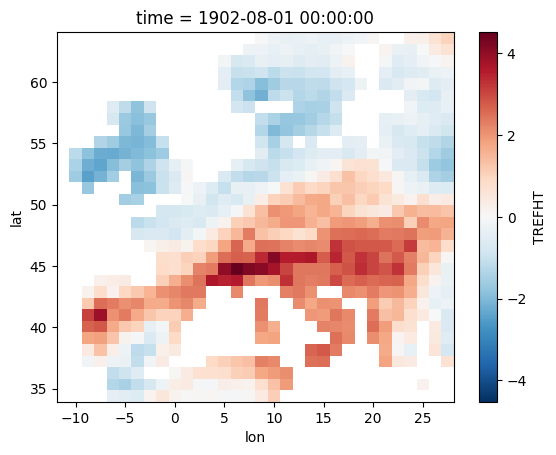

In [35]:
le_masked.isel(time=1000+71*4769).plot()

In [26]:
# 'unstack' LE
arr = le_masked   # shape: (time, lat, lon)

n_ens = 100
n_time = arr.sizes["time"] // n_ens

reshaped = arr.values.reshape(arr.sizes["lat"], arr.sizes["lon"], n_ens, n_time)
print(reshaped.shape)
arr_unstacked = xr.DataArray(
    reshaped,
    dims=("lat", "lon", "ensemble_member", "time"),
    coords={
        "ensemble_member": np.arange(1, n_ens + 1),
        "time": ds.time.isel(time=slice(0,4769)),
        "lat": arr.lat,
        "lon": arr.lon,
    },
    name="TREFHT"
)

(32, 32, 100, 4769)


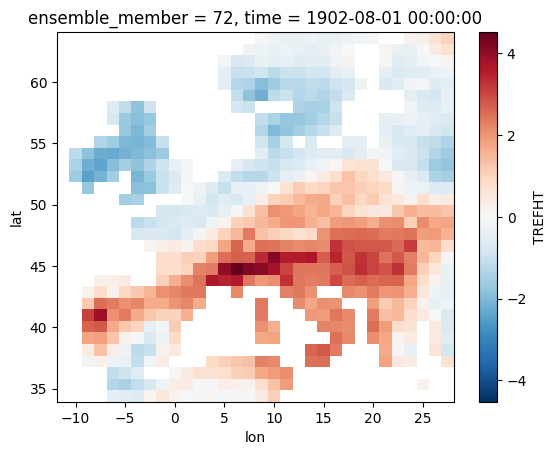

In [34]:
arr_unstacked.isel(ensemble_member=71).isel(time=1000).plot()


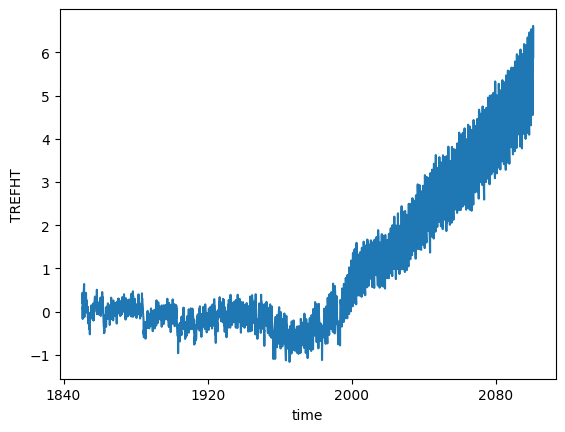

In [41]:
le_T_mean_spat_mean = arr_unstacked.mean(dim=("ensemble_member", "lat", "lon"), skipna=True)
le_T_mean_spat_mean.plot()

# ETH test

In [1]:
import torch
from torchvision.utils import make_grid
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

from engression.models import StoNet, StoLayer
from engression.loss_func import energy_loss, energy_loss_two_sample

import xarray as xr
import os
import random
import matplotlib.pyplot as plt
import argparse
import json
from sklearn.manifold import TSNE
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shutil

import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut

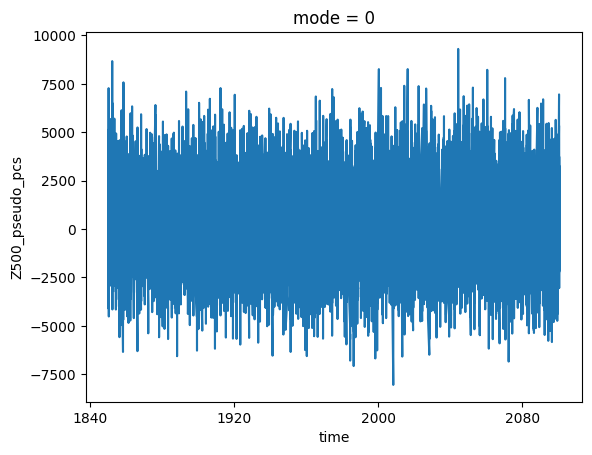

z500 dataset shape (14307, 1001)
z500 shape torch.Size([14307, 1001])


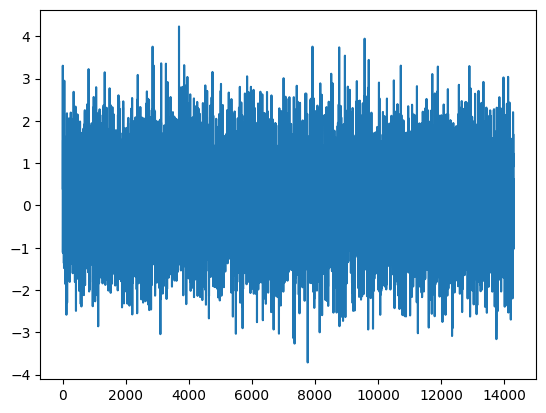

In [15]:
def load_eth_data(settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
):
    with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
    ### Load temperature data ###
    ds = xr.open_dataset(settings['dataset_z500_eth_test'])
    
    return ds

ds_z500_pre = load_eth_data()
ds.pseudo_pcs.isel(mode=0).plot()
plt.show()
ds_z500_standardized, mean, std = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 dataset shape", ds_z500_standardized.shape)
z500 = torch.from_numpy(ds_z500_standardized)
print("z500 shape", z500.shape)
plt.plot(range(14307), z500[:,0])

In [18]:
print(mean.shape)
print(std.shape)

(1, 1001)
(1, 1001)


In [ ]:
# set train/test split
    ds_train = ds.isel(time=slice(0, 128000)) 
    ds_test = ds.isel(time=slice(-64000, 476900))
    
    # transform to torch tensors
    x_tr = ut.data_to_torch(ds_train, "TREFHT")
    x_te = ut.data_to_torch(ds_test, "TREFHT")

    # remove NaNs from data
    x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
    x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)

    ### Load Z500 data ###
    ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
    ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
    print("z500 dataset shape", ds_z500.shape)
    z500 = torch.from_numpy(ds_z500)
    print("z500 shape", z500.shape)
    
    
    z500_train = z500[:int(128000),:]
    z500_test = z500[int(-64000):,:]
    
    return z500_test, mask_x_te, ds, ds_test, x_te_reduced